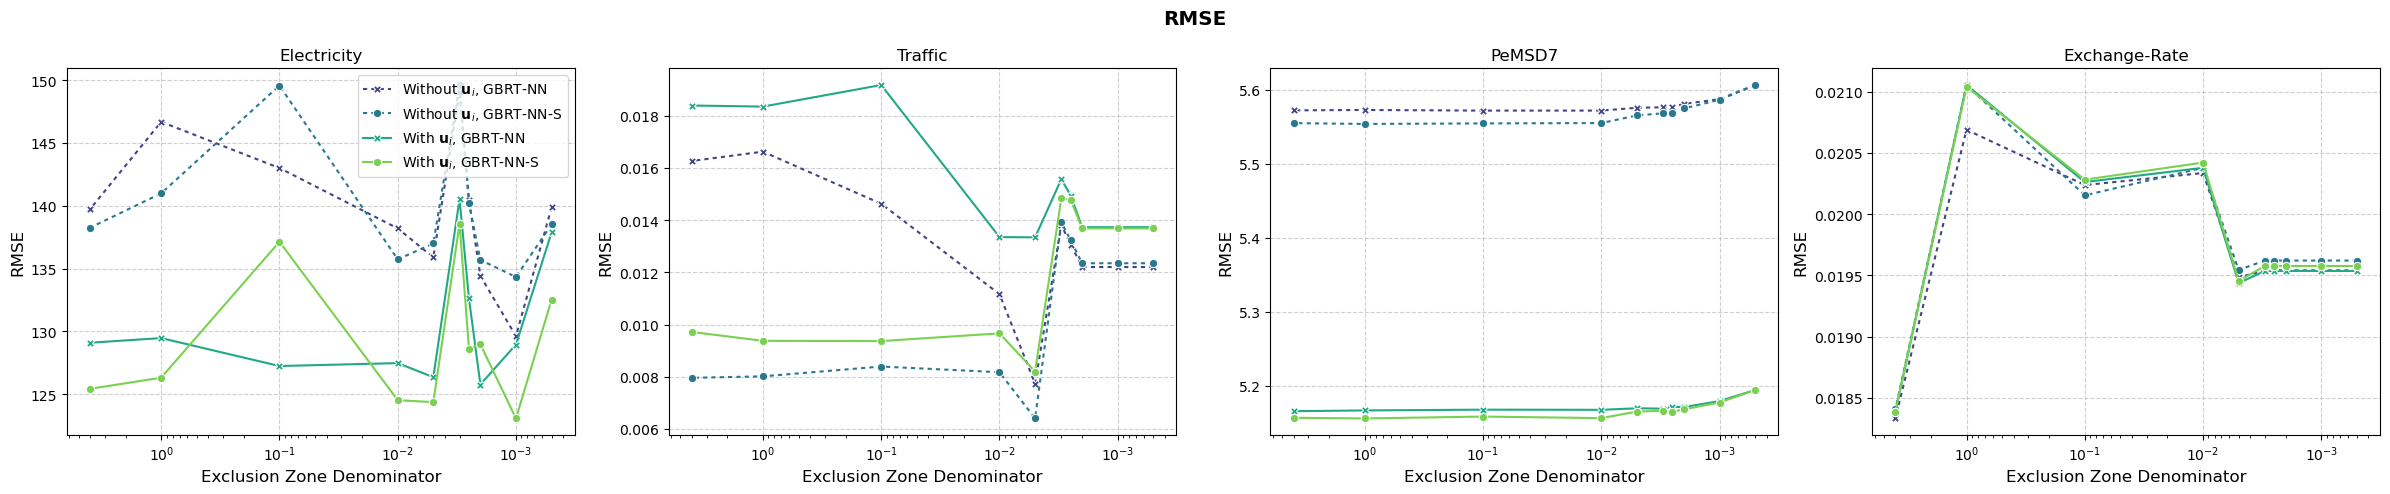

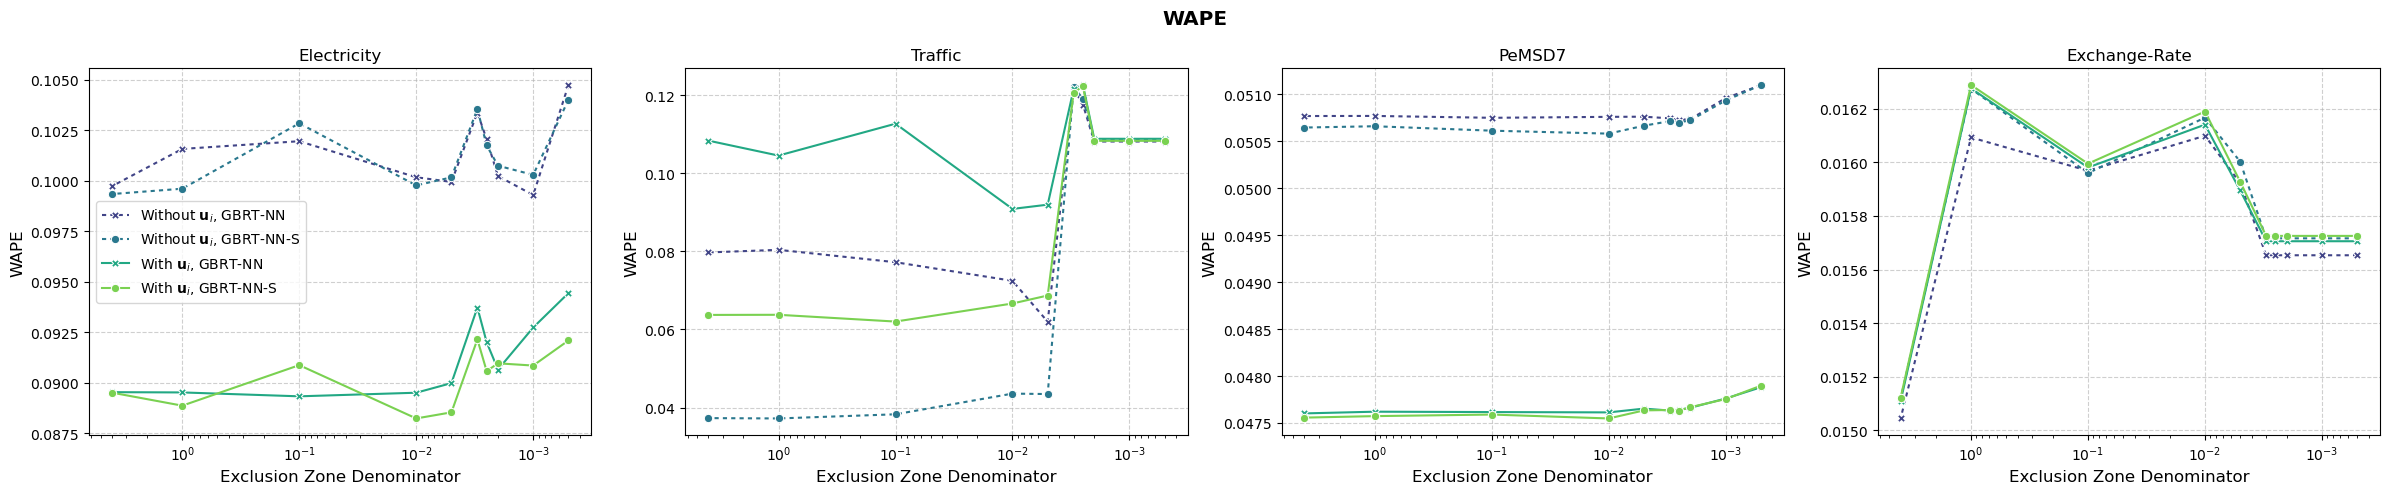

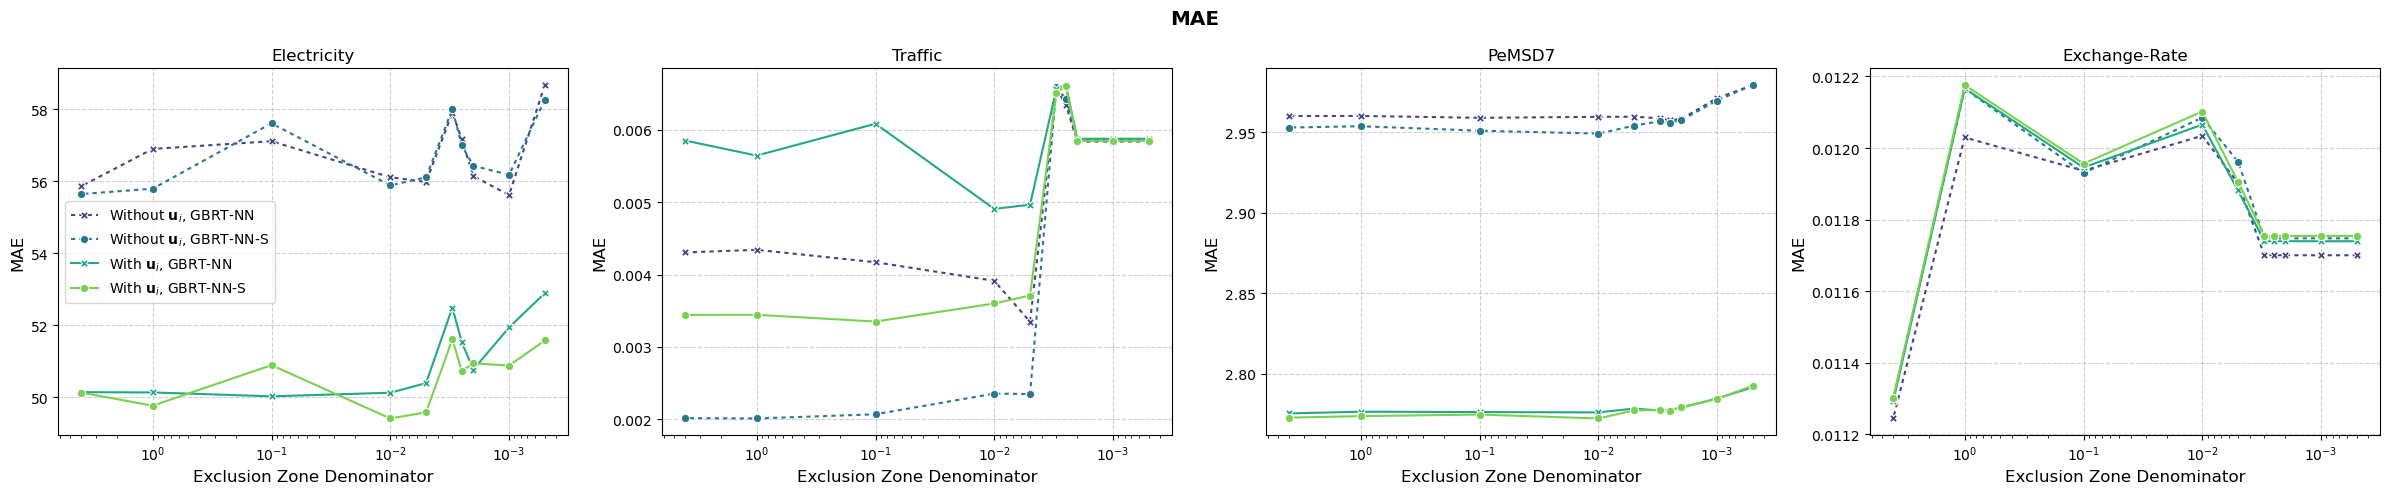

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

files = {
    "Electricity": "../results/local_daikon/3-exclusion-zone/grid_search_electricity_results_[True, False]_True_[1]_[1]_[24]_[24]_[False]_[True, False]_[4.0, 1.0, 0.1, 0.01, 0.005, 0.003, 0.0025, 0.002, 0.001, 0.0005].csv",
    "Traffic": "../results/local_daikon/3-exclusion-zone/grid_search_traffic_results_[True, False]_True_[1]_[1]_[24]_[24]_[False]_[True, False]_[4.0, 1.0, 0.1, 0.01, 0.005, 0.003, 0.0025, 0.002, 0.001, 0.0005].csv",
    "PeMSD7": "../results/local_daikon/3-exclusion-zone/grid_search_pems_results_[True, False]_True_[1]_[1]_[9]_[9]_[False]_[True, False]_[4.0, 1.0, 0.1, 0.01, 0.005, 0.003, 0.0025, 0.002, 0.001, 0.0005].csv",
    "Exchange-Rate": "../results/local_daikon/3-exclusion-zone/grid_search_exchange_rate_results_[True, False]_True_[1]_[1]_[24]_[6]_[False]_[True, False]_[4.0, 1.0, 0.1, 0.01, 0.005, 0.003, 0.0025, 0.002, 0.001, 0.0005].csv",
}

dfs = []
for ds_name, fname in files.items():
    if os.path.exists(fname):
        df = pd.read_csv(fname)
        df["dataset"] = ds_name
        # Filter: Unnormalized data only
        df = df[df["do_normalization"] == False]
        dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

# Create descriptive labels for (include_covariates, include_similarity)
combined_df["Config"] = combined_df.apply(
    lambda x: "{}, {}".format(
        (
            "With $\\mathbf{u}_i$"
            if x["include_covariates"]
            else "Without $\\mathbf{u}_i$"
        ),
        "GBRT-NN-S" if x["include_similarity"] else "GBRT-NN",
    ),
    axis=1,
)

datasets_order = ["Electricity", "Traffic", "PeMSD7", "Exchange-Rate"]

hue_order = [
    "Without $\\mathbf{u}_i$, GBRT-NN",
    "Without $\\mathbf{u}_i$, GBRT-NN-S",
    "With $\\mathbf{u}_i$, GBRT-NN",
    "With $\\mathbf{u}_i$, GBRT-NN-S",
]

dashes_map = {}
markers_map = {}

for conf in hue_order:
    if "Without $\\mathbf{u}_i$" in conf:
        dashes_map[conf] = (2, 2)
    else:
        dashes_map[conf] = ""

    if "GBRT-NN-S" in conf:
        markers_map[conf] = "o"
    else:
        markers_map[conf] = "X"

metrics = ["RMSE", "WAPE", "MAE"]

os.makedirs("../figures", exist_ok=True)

for metric in metrics:
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    for col_idx, ds in enumerate(datasets_order):
        ax = axes[col_idx]
        subset = combined_df[combined_df["dataset"] == ds]

        sns.lineplot(
            data=subset,
            x="EXCL_ZONE_DENOM",
            y=metric,
            hue="Config",
            style="Config",
            hue_order=hue_order,
            style_order=hue_order,
            markers=markers_map,
            dashes=dashes_map,
            ax=ax,
            palette="viridis",
        )

        ax.set_title(ds, fontsize="large")
        ax.set_xlabel("Exclusion Zone Denominator", fontsize="large")
        ax.set_ylabel(metric, fontsize="large")
        ax.set_xscale("log")
        ax.invert_xaxis()
        ax.grid(True, linestyle="--", alpha=0.6)

        if col_idx == 0:
            ax.legend(title="", fontsize="medium", loc="best")
        else:
            if ax.get_legend():
                ax.get_legend().remove()

    plt.tight_layout()
    if metric == "RMSE" or metric == "MAE":
        plt.savefig(f"../figures/exclusion_zone_analysis_{metric}.pdf")
    plt.show()

In [2]:
import datetime

print(f"This notebook was last run end-to-end on: {datetime.datetime.now()}\n")

This notebook was last run end-to-end on: 2026-06-15 14:03:36.355563

